In [1]:
from google.colab import files
uploaded = files.upload()

Saving iris.csv to iris.csv


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
# Load dataset
df = pd.read_csv('iris.csv')

# Display first few rows
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [4]:
# Assuming last column is target
X = df.iloc[:, :-1]   # features
y = df.iloc[:, -1]    # target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
rf_default = RandomForestClassifier(n_estimators=10, random_state=42)
rf_default.fit(X_train, y_train)

y_pred_default = rf_default.predict(X_test)

default_accuracy = accuracy_score(y_test, y_pred_default)
print("Accuracy with default n_estimators (10):", default_accuracy)

Accuracy with default n_estimators (10): 1.0


In [6]:
best_score = 0
best_n = 0

for n in [10, 20, 50, 100, 150, 200]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Accuracy with {n} trees:", acc)

    if acc > best_score:
        best_score = acc
        best_n = n

print("\nBest Accuracy:", best_score)
print("Best number of trees:", best_n)

Accuracy with 10 trees: 1.0
Accuracy with 20 trees: 1.0
Accuracy with 50 trees: 1.0
Accuracy with 100 trees: 1.0
Accuracy with 150 trees: 1.0
Accuracy with 200 trees: 1.0

Best Accuracy: 1.0
Best number of trees: 10


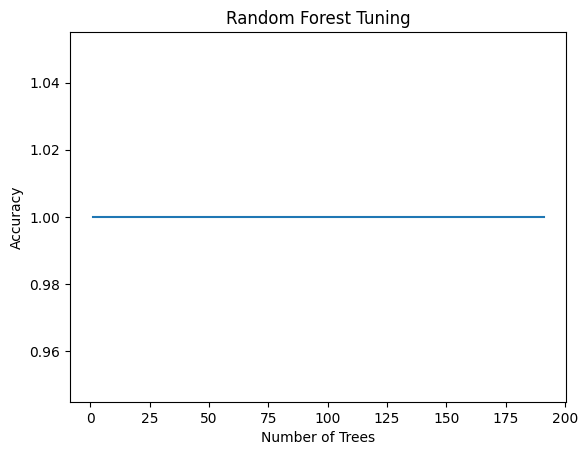

In [7]:
import matplotlib.pyplot as plt

scores = []
tree_range = range(1, 201, 10)

for n in tree_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

# Plot graph
plt.plot(tree_range, scores)
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest Tuning")
plt.show()